In [82]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [83]:
stage = "river"

### Reading and compacting dfs

In [84]:
compact = False

In [85]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact:
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage
0,0.000830,0.000879,0.000613,0.001353,0.000308,0.001040,0.000633,0.000741,0.001298,0.001409,...,0,238,0,238,True,False,False,476,1999,river
1,0.000088,0.000148,0.000140,0.000489,0.000314,0.000369,0.000840,0.000462,0.000833,0.001442,...,216,446,476,706,True,True,True,1152,2332,river
2,0.000744,0.000143,0.000053,0.000619,0.000629,0.001361,0.001054,0.001156,0.000346,0.000506,...,23,98,105,180,True,True,True,278,1531,river
3,0.000317,0.001410,0.000728,0.000092,0.000536,0.000907,0.001112,0.001330,0.000833,0.000587,...,25,70,66,111,True,True,True,181,1684,river
4,0.001123,0.000399,0.000457,0.001393,0.000111,0.001093,0.000376,0.000669,0.001512,0.001473,...,275,591,631,947,True,True,True,1538,2785,river
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.000925,0.000925,0.000925,0.000925,0.000925,0.000000,0.000000,0.000925,0.000925,0.000925,...,0,5,0,5,True,False,True,10,200,river
135,0.000971,0.000971,0.000970,0.000985,0.000969,0.000000,0.000000,0.000965,0.000977,0.000956,...,0,2,0,2,True,False,True,4,200,river
136,0.001724,0.002065,0.001722,0.001704,0.001718,0.000000,0.000000,0.002052,0.001790,0.001711,...,0,74,0,74,True,False,True,148,200,river
137,0.001724,0.002065,0.001722,0.001704,0.001718,0.000000,0.000000,0.002052,0.001790,0.001711,...,0,2,0,2,True,False,True,4,200,river


In [86]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000830,0.000879,0.000613,0.001353,0.000308,0.001040,0.000633,0.000741,0.001298,0.001409,...,0.0,0,238,0,238,True,False,False,476,1999
1,0.000088,0.000148,0.000140,0.000489,0.000314,0.000369,0.000840,0.000462,0.000833,0.001442,...,0.0,216,446,476,706,True,True,True,1152,2332
2,0.000744,0.000143,0.000053,0.000619,0.000629,0.001361,0.001054,0.001156,0.000346,0.000506,...,0.0,23,98,105,180,True,True,True,278,1531
3,0.000317,0.001410,0.000728,0.000092,0.000536,0.000907,0.001112,0.001330,0.000833,0.000587,...,0.0,25,70,66,111,True,True,True,181,1684
4,0.001123,0.000399,0.000457,0.001393,0.000111,0.001093,0.000376,0.000669,0.001512,0.001473,...,0.0,275,591,631,947,True,True,True,1538,2785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.000925,0.000925,0.000925,0.000925,0.000925,0.000000,0.000000,0.000925,0.000925,0.000925,...,0.0,0,5,0,5,True,False,True,10,200
135,0.000971,0.000971,0.000970,0.000985,0.000969,0.000000,0.000000,0.000965,0.000977,0.000956,...,0.0,0,2,0,2,True,False,True,4,200
136,0.001724,0.002065,0.001722,0.001704,0.001718,0.000000,0.000000,0.002052,0.001790,0.001711,...,0.0,0,74,0,74,True,False,True,148,200
137,0.001724,0.002065,0.001722,0.001704,0.001718,0.000000,0.000000,0.002052,0.001790,0.001711,...,0.0,0,2,0,2,True,False,True,4,200


### Preprocessing

In [87]:
# Divide all bets by game_size
def scale_bets(df):
    bet_columns = [
        "player_bet_in_stage",
        "player_bet_in_game",
        "opponent_bet_in_stage",
        "opponent_bet_in_game",
        "pot",
    ]
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000830,0.000879,0.000613,0.001353,0.000308,0.001040,0.000633,0.000741,0.001298,0.001409,...,0.0,0.000000,0.119060,0.000000,0.119060,True,False,False,0.238119,1999
1,0.000088,0.000148,0.000140,0.000489,0.000314,0.000369,0.000840,0.000462,0.000833,0.001442,...,0.0,0.092624,0.191252,0.204117,0.302744,True,True,True,0.493997,2332
2,0.000744,0.000143,0.000053,0.000619,0.000629,0.001361,0.001054,0.001156,0.000346,0.000506,...,0.0,0.015023,0.064010,0.068583,0.117570,True,True,True,0.181581,1531
3,0.000317,0.001410,0.000728,0.000092,0.000536,0.000907,0.001112,0.001330,0.000833,0.000587,...,0.0,0.014846,0.041568,0.039192,0.065914,True,True,True,0.107482,1684
4,0.001123,0.000399,0.000457,0.001393,0.000111,0.001093,0.000376,0.000669,0.001512,0.001473,...,0.0,0.098743,0.212208,0.226571,0.340036,True,True,True,0.552244,2785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.000925,0.000925,0.000925,0.000925,0.000925,0.000000,0.000000,0.000925,0.000925,0.000925,...,0.0,0.000000,0.025000,0.000000,0.025000,True,False,True,0.050000,200
135,0.000971,0.000971,0.000970,0.000985,0.000969,0.000000,0.000000,0.000965,0.000977,0.000956,...,0.0,0.000000,0.010000,0.000000,0.010000,True,False,True,0.020000,200
136,0.001724,0.002065,0.001722,0.001704,0.001718,0.000000,0.000000,0.002052,0.001790,0.001711,...,0.0,0.000000,0.370000,0.000000,0.370000,True,False,True,0.740000,200
137,0.001724,0.002065,0.001722,0.001704,0.001718,0.000000,0.000000,0.002052,0.001790,0.001711,...,0.0,0.000000,0.010000,0.000000,0.010000,True,False,True,0.020000,200


In [88]:
# Scale range features so that min is 0 and mean is 0.5
def scale_ranges(df, training_min, training_mean):
    range_columns = [col for col in df.columns if col.startswith("prob_")]
    df[range_columns] = (df[range_columns] - training_min) / (training_mean - training_min) * 0.5
    return df

def get_training_min_and_mean(df):
    range_columns = [col for col in df.columns if col.startswith("prob_")]
    training_min = df[range_columns].to_numpy().min()
    training_mean = df[range_columns].to_numpy().mean()
    return training_min, training_mean

scale_ranges(df, *get_training_min_and_mean(df))
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.550505,0.582608,0.406540,0.897164,0.204029,0.689779,0.419402,0.491400,0.860770,0.934060,...,0.0,0.000000,0.119060,0.000000,0.119060,True,False,False,0.238119,1999
1,0.058311,0.097906,0.092796,0.324454,0.208066,0.244363,0.557026,0.306439,0.552302,0.955878,...,0.0,0.092624,0.191252,0.204117,0.302744,True,True,True,0.493997,2332
2,0.493222,0.094849,0.035419,0.410223,0.416734,0.902670,0.698779,0.766646,0.229261,0.335686,...,0.0,0.015023,0.064010,0.068583,0.117570,True,True,True,0.181581,1531
3,0.210276,0.934989,0.482528,0.061092,0.355432,0.601563,0.736937,0.881672,0.552081,0.389308,...,0.0,0.014846,0.041568,0.039192,0.065914,True,True,True,0.107482,1684
4,0.744805,0.264490,0.302706,0.923772,0.073478,0.724335,0.249229,0.443827,1.002433,0.976792,...,0.0,0.098743,0.212208,0.226571,0.340036,True,True,True,0.552244,2785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.613321,0.613321,0.613321,0.613321,0.613321,0.000000,0.000000,0.613321,0.613321,0.613321,...,0.0,0.000000,0.025000,0.000000,0.025000,True,False,True,0.050000,200
135,0.643714,0.643713,0.642870,0.652921,0.642757,0.000000,0.000000,0.639726,0.647585,0.634080,...,0.0,0.000000,0.010000,0.000000,0.010000,True,False,True,0.020000,200
136,1.143235,1.369080,1.141606,1.129442,1.139256,0.000000,0.000000,1.360599,1.186836,1.134159,...,0.0,0.000000,0.370000,0.000000,0.370000,True,False,True,0.740000,200
137,1.143235,1.369080,1.141606,1.129442,1.139256,0.000000,0.000000,1.360599,1.186836,1.134159,...,0.0,0.000000,0.010000,0.000000,0.010000,True,False,True,0.020000,200


In [89]:
# Make boolean features 0 or 1
def encode_bools(df):
    bool_columns = [
        "player_turn",
        "player_has_bet",
        "opponent_has_bet",
    ]
    df[bool_columns] = df[bool_columns].astype(int)
    return df

df = encode_bools(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.550505,0.582608,0.406540,0.897164,0.204029,0.689779,0.419402,0.491400,0.860770,0.934060,...,0.0,0.000000,0.119060,0.000000,0.119060,1,0,0,0.238119,1999
1,0.058311,0.097906,0.092796,0.324454,0.208066,0.244363,0.557026,0.306439,0.552302,0.955878,...,0.0,0.092624,0.191252,0.204117,0.302744,1,1,1,0.493997,2332
2,0.493222,0.094849,0.035419,0.410223,0.416734,0.902670,0.698779,0.766646,0.229261,0.335686,...,0.0,0.015023,0.064010,0.068583,0.117570,1,1,1,0.181581,1531
3,0.210276,0.934989,0.482528,0.061092,0.355432,0.601563,0.736937,0.881672,0.552081,0.389308,...,0.0,0.014846,0.041568,0.039192,0.065914,1,1,1,0.107482,1684
4,0.744805,0.264490,0.302706,0.923772,0.073478,0.724335,0.249229,0.443827,1.002433,0.976792,...,0.0,0.098743,0.212208,0.226571,0.340036,1,1,1,0.552244,2785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.613321,0.613321,0.613321,0.613321,0.613321,0.000000,0.000000,0.613321,0.613321,0.613321,...,0.0,0.000000,0.025000,0.000000,0.025000,1,0,1,0.050000,200
135,0.643714,0.643713,0.642870,0.652921,0.642757,0.000000,0.000000,0.639726,0.647585,0.634080,...,0.0,0.000000,0.010000,0.000000,0.010000,1,0,1,0.020000,200
136,1.143235,1.369080,1.141606,1.129442,1.139256,0.000000,0.000000,1.360599,1.186836,1.134159,...,0.0,0.000000,0.370000,0.000000,0.370000,1,0,1,0.740000,200
137,1.143235,1.369080,1.141606,1.129442,1.139256,0.000000,0.000000,1.360599,1.186836,1.134159,...,0.0,0.000000,0.010000,0.000000,0.010000,1,0,1,0.020000,200


In [90]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,0.550505,0.582608,0.406540,0.897164,0.204029,0.689779,0.419402,0.491400,0.860770,0.934060,...,0.0,0.0,0.000000,0.119060,0.000000,0.119060,1,0,0,0.238119
1,0.058311,0.097906,0.092796,0.324454,0.208066,0.244363,0.557026,0.306439,0.552302,0.955878,...,0.0,0.0,0.092624,0.191252,0.204117,0.302744,1,1,1,0.493997
2,0.493222,0.094849,0.035419,0.410223,0.416734,0.902670,0.698779,0.766646,0.229261,0.335686,...,0.0,0.0,0.015023,0.064010,0.068583,0.117570,1,1,1,0.181581
3,0.210276,0.934989,0.482528,0.061092,0.355432,0.601563,0.736937,0.881672,0.552081,0.389308,...,0.0,0.0,0.014846,0.041568,0.039192,0.065914,1,1,1,0.107482
4,0.744805,0.264490,0.302706,0.923772,0.073478,0.724335,0.249229,0.443827,1.002433,0.976792,...,0.0,0.0,0.098743,0.212208,0.226571,0.340036,1,1,1,0.552244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.613321,0.613321,0.613321,0.613321,0.613321,0.000000,0.000000,0.613321,0.613321,0.613321,...,0.0,0.0,0.000000,0.025000,0.000000,0.025000,1,0,1,0.050000
135,0.643714,0.643713,0.642870,0.652921,0.642757,0.000000,0.000000,0.639726,0.647585,0.634080,...,0.0,0.0,0.000000,0.010000,0.000000,0.010000,1,0,1,0.020000
136,1.143235,1.369080,1.141606,1.129442,1.139256,0.000000,0.000000,1.360599,1.186836,1.134159,...,0.0,0.0,0.000000,0.370000,0.000000,0.370000,1,0,1,0.740000
137,1.143235,1.369080,1.141606,1.129442,1.139256,0.000000,0.000000,1.360599,1.186836,1.134159,...,0.0,0.0,0.000000,0.010000,0.000000,0.010000,1,0,1,0.020000


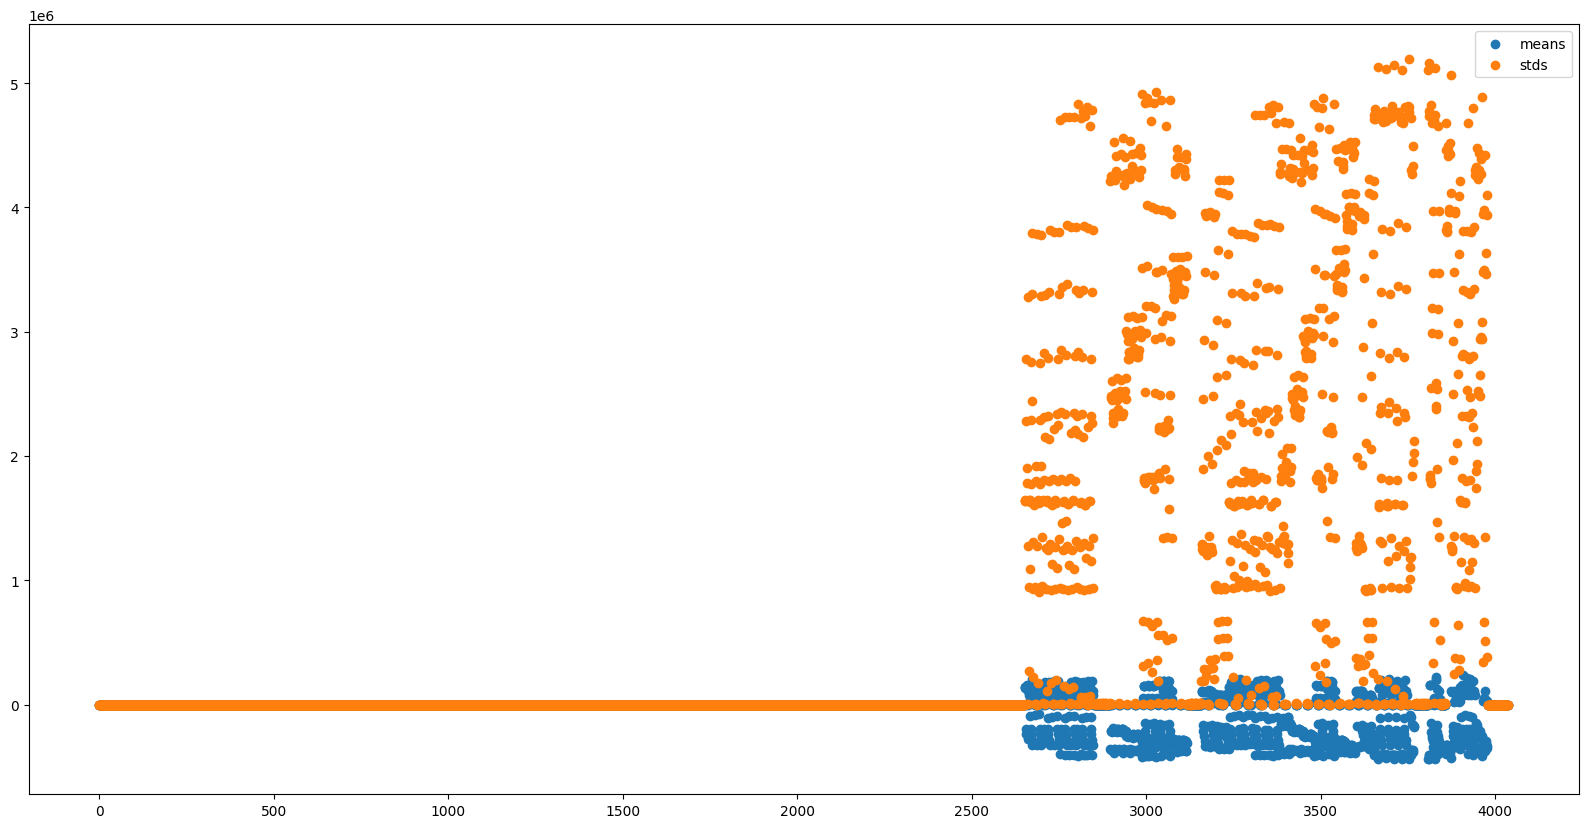

In [91]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means")
plt.scatter(range(df.std().size), df.std(), label="stds")
plt.legend()
plt.show()

In [92]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(139, 2712) (139, 1326)
